## PROBLEM STATEMENT
The COVID-19 pandemic has posed unprecedented challenges to global healthcare systems, making accurate forecasting of its outcomes critical for effective planning and intervention. This project focuses on predicting the daily number of deaths and recoveries using the Johns Hopkins COVID-19 time series dataset, which provides comprehensive records of reported cases across multiple regions. The main objective is to develop a predictive model capable of capturing temporal trends, seasonality, and sudden anomalies caused by outbreaks or reporting inconsistencies. Key challenges include handling missing data, addressing irregular reporting patterns, and managing outliers to ensure reliable predictions. By accurately forecasting future deaths and recoveries, the model aims to support healthcare authorities and policymakers in allocating resources efficiently, planning preventive measures, and making data-driven decisions. Additionally, the insights gained from this project can be extended to improve forecasting approaches for other infectious diseases in the future.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

BASIC CHECKS

In [ ]:
confirmed = pd.read_csv('time_series_covid19_confirmed_global.csv')
deaths = pd.read_csv('time_series_covid19_deaths_global.csv')
recovered = pd.read_csv('time_series_covid19_recovered_global.csv')

In [ ]:
cols_to_drop = ['Province/State', 'Lat', 'Long']

confirmed = confirmed.drop(columns=cols_to_drop)
deaths = deaths.drop(columns=cols_to_drop)
recovered = recovered.drop(columns=cols_to_drop)

In [ ]:
confirmed = confirmed.groupby('Country/Region').sum()
deaths = deaths.groupby('Country/Region').sum()
recovered = recovered.groupby('Country/Region').sum()

In [ ]:
confirmed_ts = confirmed.sum()
deaths_ts = deaths.sum()
recovered_ts = recovered.sum()

In [ ]:
confirmed_ts.index = pd.to_datetime(confirmed_ts.index)
deaths_ts.index = pd.to_datetime(deaths_ts.index)
recovered_ts.index = pd.to_datetime(recovered_ts.index)

/tmp/ipykernel_5835/740227174.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  confirmed_ts.index = pd.to_datetime(confirmed_ts.index)
/tmp/ipykernel_5835/740227174.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  deaths_ts.index = pd.to_datetime(deaths_ts.index)
/tmp/ipykernel_5835/740227174.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  recovered_ts.index = pd.to_datetime(recovered_ts.index)


In [ ]:
df = pd.DataFrame({
    'Confirmed': confirmed_ts,
    'Deaths': deaths_ts,
    'Recovered': recovered_ts
})

In [ ]:
df.head()

,Confirmed,Deaths,Recovered
2020-01-22,555,17,28
2020-01-23,654,18,30
2020-01-24,941,26,36
2020-01-25,1434,42,39
2020-01-26,2118,56,52


In [ ]:
df.describe()

,Confirmed,Deaths,Recovered
count,2.440000e+02,244.000000,2.440000e+02
mean,8.879640e+06,364770.413934,5.171252e+06
std,9.431867e+06,314325.583567,6.326455e+06
min,5.550000e+02,17.000000,2.800000e+01
25%,3.739185e+05,16311.250000,9.823450e+04
50%,5.271320e+06,342796.500000,2.080976e+06
75%,1.529584e+07,622394.250000,8.686263e+06
max,3.124580e+07,963693.000000,2.139459e+07


In [ ]:
df.head()

,Confirmed,Deaths,Recovered
2020-01-22,555,17,28
2020-01-23,654,18,30
2020-01-24,941,26,36
2020-01-25,1434,42,39
2020-01-26,2118,56,52


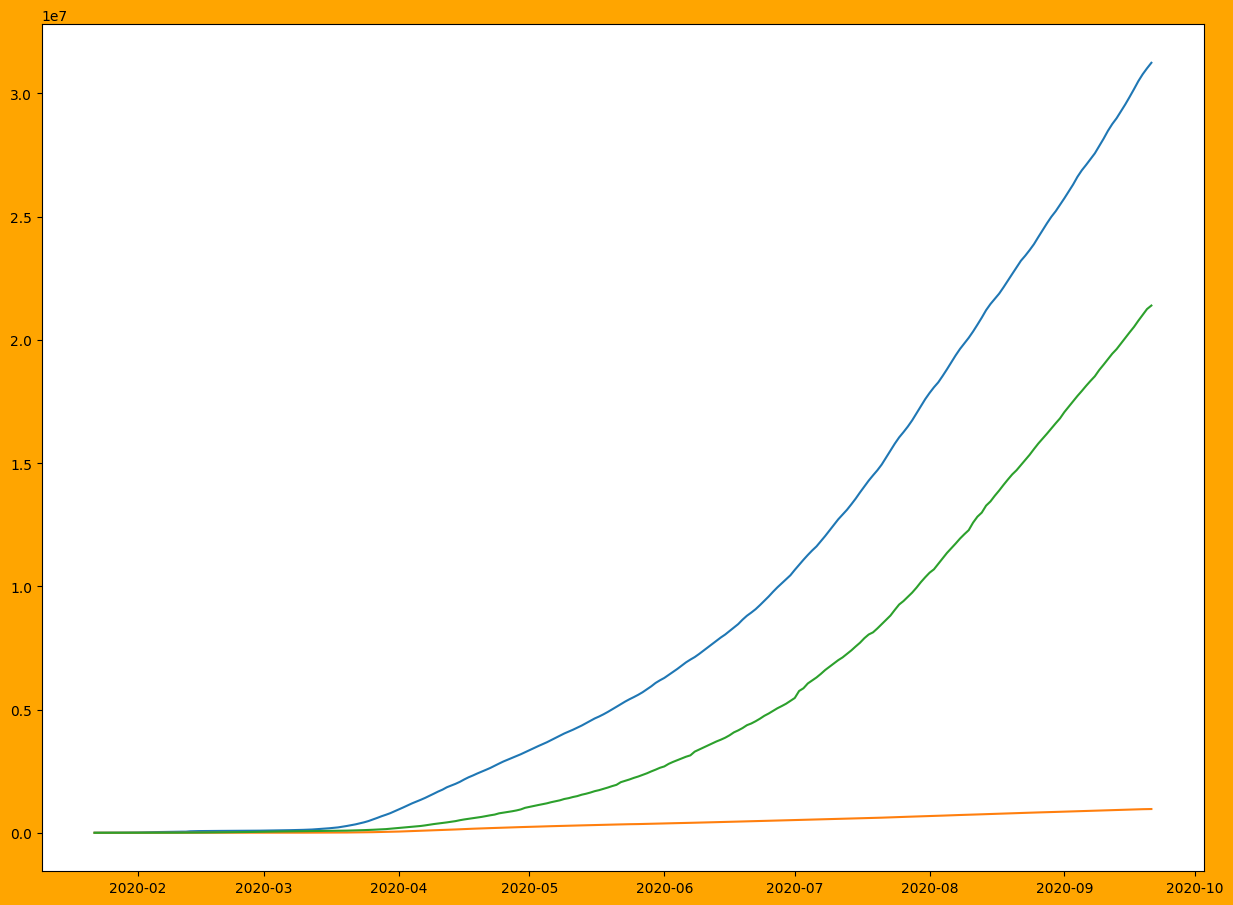

In [ ]:
plt.figure(figsize=(15,11),facecolor='orange')#canvas  size

plt.plot(df)

In [ ]:
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))

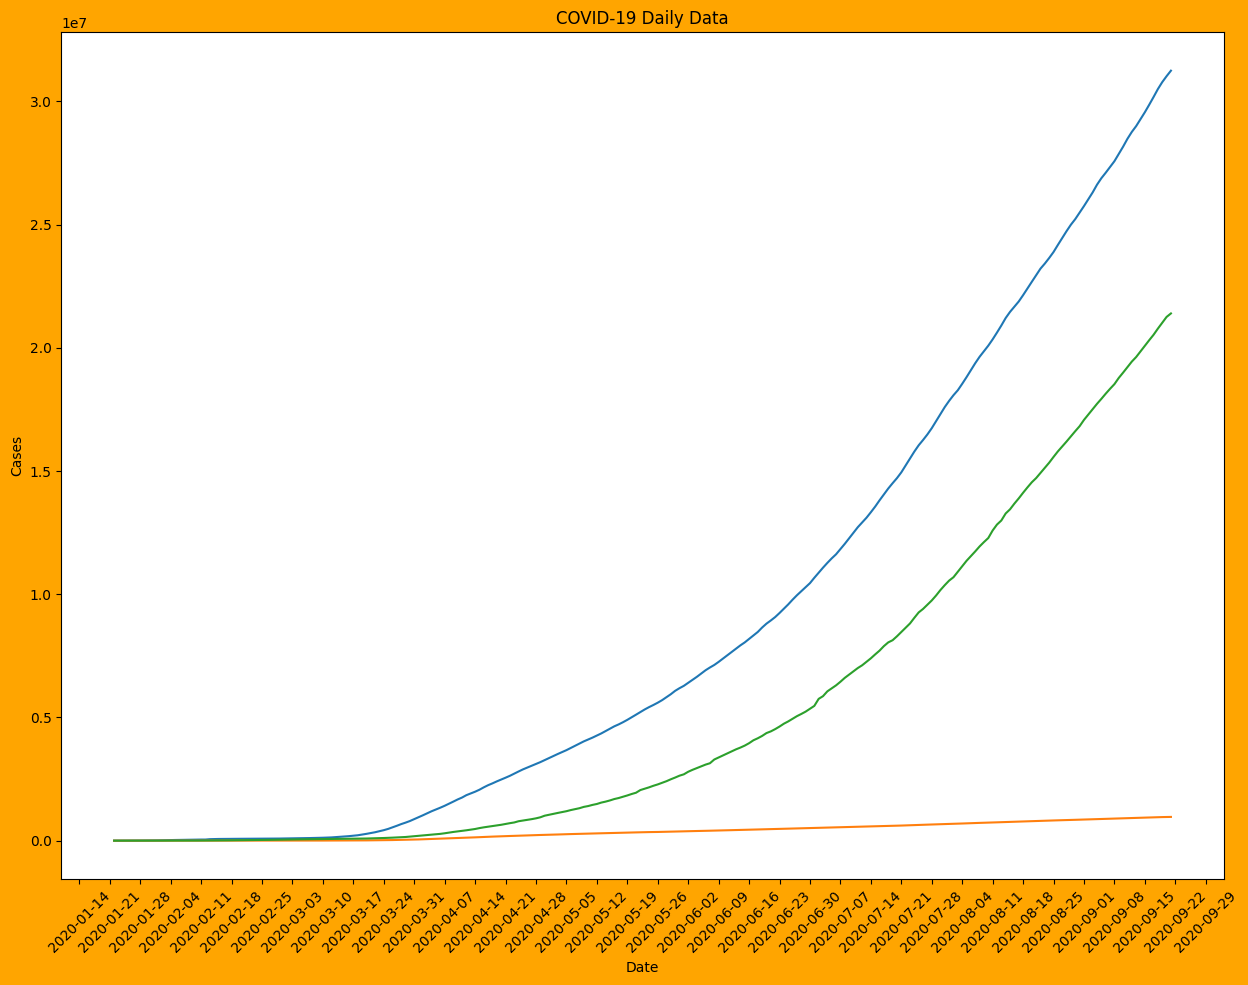

In [ ]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(15,11), facecolor='orange')

ax.plot(df)

ax.set_title("COVID-19 Daily Data")
ax.set_xlabel("Date")
ax.set_ylabel("Cases")

# Set ticks every 7 days
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.xticks(rotation=45)

plt.show()

ADFULLER TEST

In [ ]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series.dropna())

    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations']
    for value,label in zip(result,labels):
        print(label+' : '+str(value))

    if result[1] <= 0.05:
        print("Strong evidence against null hypothesis")
        print("Reject null hypothesis")
        print("Data is Stationary")
    else:
        print("Weak evidence against null hypothesis")
        print("Fail to reject null hypothesis")
        print("Data is Non-Stationary")

In [ ]:
adf_test(df['Confirmed'])

ADF Test Statistic : -1.26143950091348
p-value : 0.6466240713103429
#Lags Used : 15
Number of Observations : 228
Weak evidence against null hypothesis
Fail to reject null hypothesis
Data is Non-Stationary


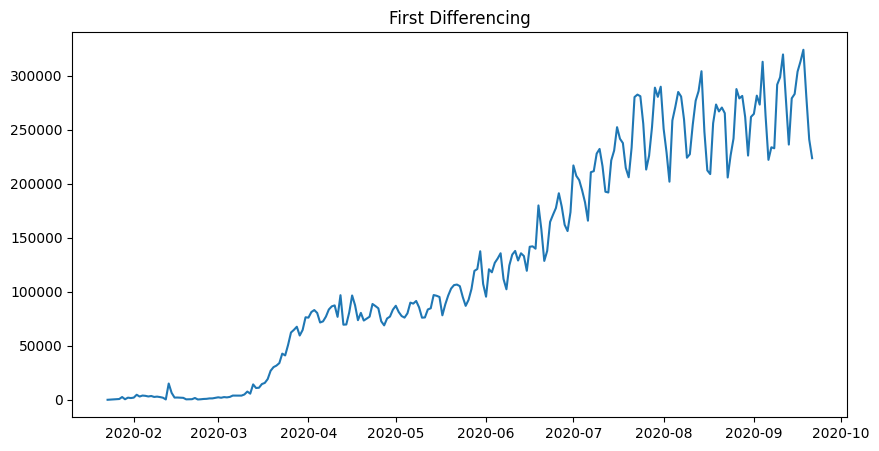

In [ ]:
df_diff = df['Confirmed'].diff().dropna()

plt.figure(figsize=(10,5))
plt.plot(df_diff)
plt.title("First Differencing")
plt.show()

In [ ]:
adf_test(df_diff)

ADF Test Statistic : -0.604982860402845
p-value : 0.8698521247285387
#Lags Used : 15
Number of Observations : 227
Weak evidence against null hypothesis
Fail to reject null hypothesis
Data is Non-Stationary


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

<Figure size 1000x500 with 0 Axes>

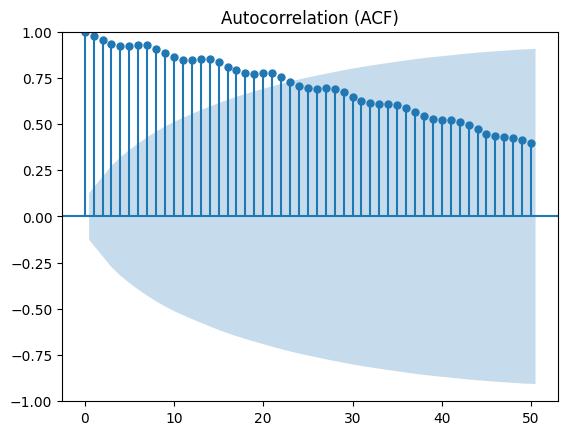

In [ ]:
plt.figure(figsize=(10,5))
plot_acf(df_diff, lags=50)
plt.title("Autocorrelation (ACF)")
plt.show()

<Figure size 1000x500 with 0 Axes>

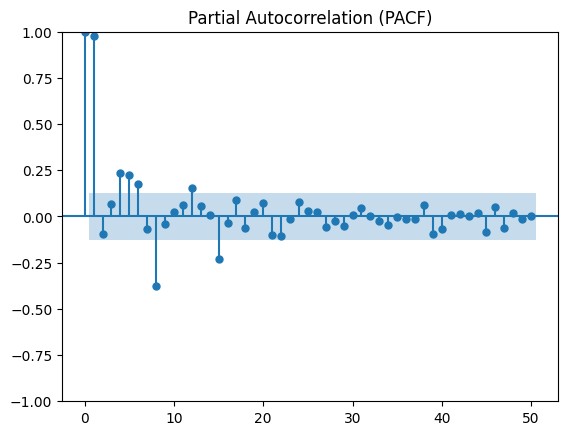

In [ ]:
plt.figure(figsize=(10,5))
plot_pacf(df_diff, lags=50)
plt.title("Partial Autocorrelation (PACF)")
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

dftest = adfuller(df['Confirmed'])

print("1. ADF :", dftest[0])
print("2. P-Value :", dftest[1])
print("3. Num Of Lags :", dftest[2])
print("4. Num Of Observations Used For ADF Regression and Critical Values Calculation :", dftest[3])
print("5. Critical Values :")

for key, val in dftest[4].items():
    print("\t", key, ":", val)

1. ADF : -1.26143950091348
2. P-Value : 0.6466240713103429
3. Num Of Lags : 15
4. Num Of Observations Used For ADF Regression and Critical Values Calculation : 228
5. Critical Values :
	 1% : -3.4593607492757554
	 5% : -2.8743015807562924
	 10% : -2.5735714042782396


In [ ]:
data1 = df['Confirmed'].diff(periods=1)
data1 = data1.dropna()

print(data1.head())

2020-01-23     99.0
2020-01-24    287.0
2020-01-25    493.0
2020-01-26    684.0
2020-01-27    809.0
Name: Confirmed, dtype: float64


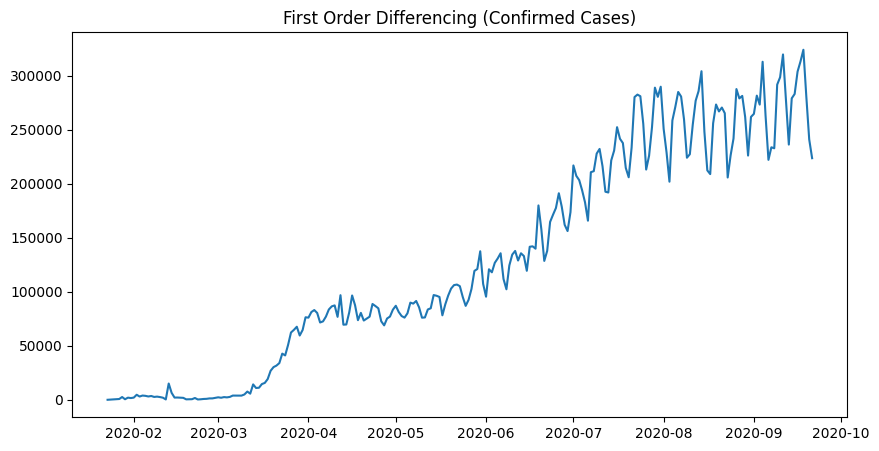

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(data1)
plt.title("First Order Differencing (Confirmed Cases)")
plt.show()

In [ ]:
confirmed_diff = df['Confirmed'].diff(periods=1).dropna()

In [ ]:
deaths_diff = df['Deaths'].diff(periods=1).dropna()

print(deaths_diff.head())

2020-01-23     1.0
2020-01-24     8.0
2020-01-25    16.0
2020-01-26    14.0
2020-01-27    26.0
Name: Deaths, dtype: float64


In [ ]:
recovered_diff = df['Recovered'].diff(periods=1).dropna()

print(recovered_diff.head())

2020-01-23     2.0
2020-01-24     6.0
2020-01-25     3.0
2020-01-26    13.0
2020-01-27     9.0
Name: Recovered, dtype: float64


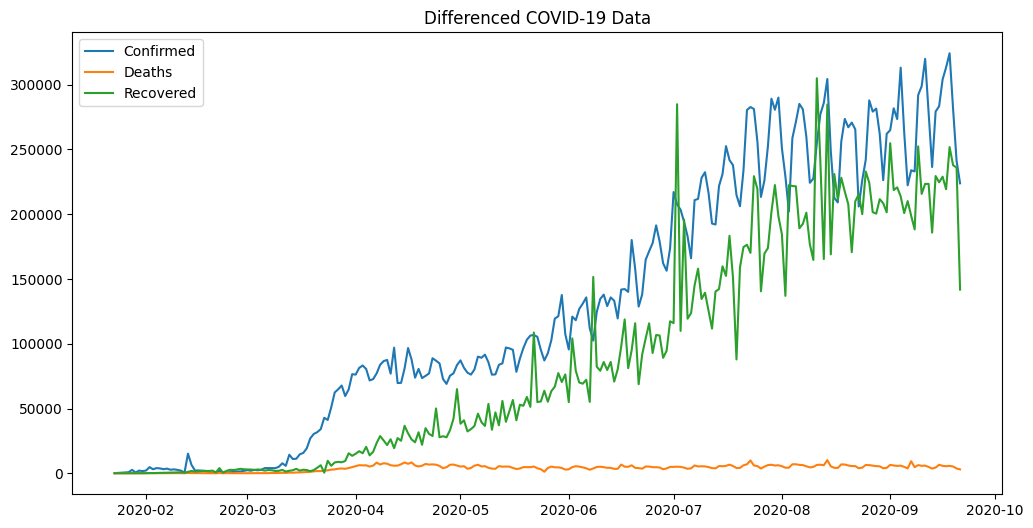

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(confirmed_diff, label='Confirmed')
plt.plot(deaths_diff, label='Deaths')
plt.plot(recovered_diff, label='Recovered')

plt.legend()
plt.title("Differenced COVID-19 Data")
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

print("Confirmed Data ADF Test:\n")

dftest = adfuller(confirmed_diff)

print("1. ADF :", dftest[0])
print("2. P-Value :", dftest[1])
print("3. Num Of Lags :", dftest[2])
print("4. Num Of Observations Used :", dftest[3])
print("5. Critical Values :")

for key, val in dftest[4].items():
    print("\t", key, ":", val)

Confirmed Data ADF Test:

1. ADF : -0.604982860402845
2. P-Value : 0.8698521247285387
3. Num Of Lags : 15
4. Num Of Observations Used : 227
5. Critical Values :
	 1% : -3.4594900381360034
	 5% : -2.8743581895178485
	 10% : -2.573601605503697


In [ ]:
print("\nDeaths Data ADF Test:\n")

dftest = adfuller(deaths_diff)

print("1. ADF :", dftest[0])
print("2. P-Value :", dftest[1])
print("3. Num Of Lags :", dftest[2])
print("4. Num Of Observations Used :", dftest[3])
print("5. Critical Values :")

for key, val in dftest[4].items():
    print("\t", key, ":", val)


Deaths Data ADF Test:

1. ADF : -2.321128567383488
2. P-Value : 0.1652441044521072
3. Num Of Lags : 11
4. Num Of Observations Used : 231
5. Critical Values :
	 1% : -3.4589796764641
	 5% : -2.8741347158661448
	 10% : -2.573482381701992


In [ ]:
print("\nRecovered Data ADF Test:\n")

dftest = adfuller(recovered_diff)

print("1. ADF :", dftest[0])
print("2. P-Value :", dftest[1])
print("3. Num Of Lags :", dftest[2])
print("4. Num Of Observations Used :", dftest[3])
print("5. Critical Values :")

for key, val in dftest[4].items():
    print("\t", key, ":", val)


Recovered Data ADF Test:

1. ADF : 0.46780473269037615
2. P-Value : 0.9838609899496281
3. Num Of Lags : 7
4. Num Of Observations Used : 235
5. Critical Values :
	 1% : -3.4584868856997004
	 5% : -2.873918902362675
	 10% : -2.573367247623359


In [ ]:
recovered_diff2 = recovered_diff.diff(periods=1).dropna()

print(recovered_diff2.head())

2020-01-24     4.0
2020-01-25    -3.0
2020-01-26    10.0
2020-01-27    -4.0
2020-01-28    37.0
Name: Recovered, dtype: float64


In [ ]:
from statsmodels.tsa.stattools import adfuller

print("Recovered Data ADF Test (After 2nd Differencing):\n")

dftest = adfuller(recovered_diff2)

print("1. ADF :", dftest[0])
print("2. P-Value :", dftest[1])
print("3. Num Of Lags :", dftest[2])
print("4. Num Of Observations Used :", dftest[3])
print("5. Critical Values :")

for key, val in dftest[4].items():
    print("\t", key, ":", val)

Recovered Data ADF Test (After 2nd Differencing):

1. ADF : -11.243439688968808
2. P-Value : 1.7835618806397916e-20
3. Num Of Lags : 6
4. Num Of Observations Used : 235
5. Critical Values :
	 1% : -3.4584868856997004
	 5% : -2.873918902362675
	 10% : -2.573367247623359


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = df['Confirmed']

train = data[:100]
test = data[100:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 100
Test size: 144


In [ ]:
data = df['Deaths']

train = data[:100]
test = data[100:]

In [ ]:
from statsmodels.tsa.ar_model import ar_select_order

mod = ar_select_order(data, maxlag=15, glob=True)
print("Best Lags:", mod.ar_lags)

Best Lags: [1, 9, 13, 15]


In [ ]:
from statsmodels.tsa.ar_model import AutoReg

ar_model = AutoReg(train, lags=mod.ar_lags)
ar_model_fit = ar_model.fit()

print(ar_model_fit.summary())

                            AutoReg Model Results                             
Dep. Variable:                 Deaths   No. Observations:                  100
Model:             Restr. AutoReg(15)   Log Likelihood                -638.491
Method:               Conditional MLE   S.D. of innovations            442.623
Date:                Sun, 29 Mar 2026   AIC                           1288.982
Time:                        08:52:36   BIC                           1303.638
Sample:                    02-06-2020   HQIC                          1294.877
                         - 04-30-2020                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        106.2946     67.014      1.586      0.113     -25.051     237.640
Deaths.L1      1.2366      0.009    130.722      0.000       1.218       1.255
Deaths.L9     -0.5807      0.037    -15.622      0.0

In [ ]:
len(test)

144

In [ ]:
start = len(train)
end = len(train) + len(test) - 1

prediction = ar_model_fit.predict(start=start, end=end)

print(prediction.head())

2020-05-01    242623.678601
2020-05-02    247418.158172
2020-05-03    251501.568608
2020-05-04    256145.428679
2020-05-05    262110.640813
Freq: D, dtype: float64


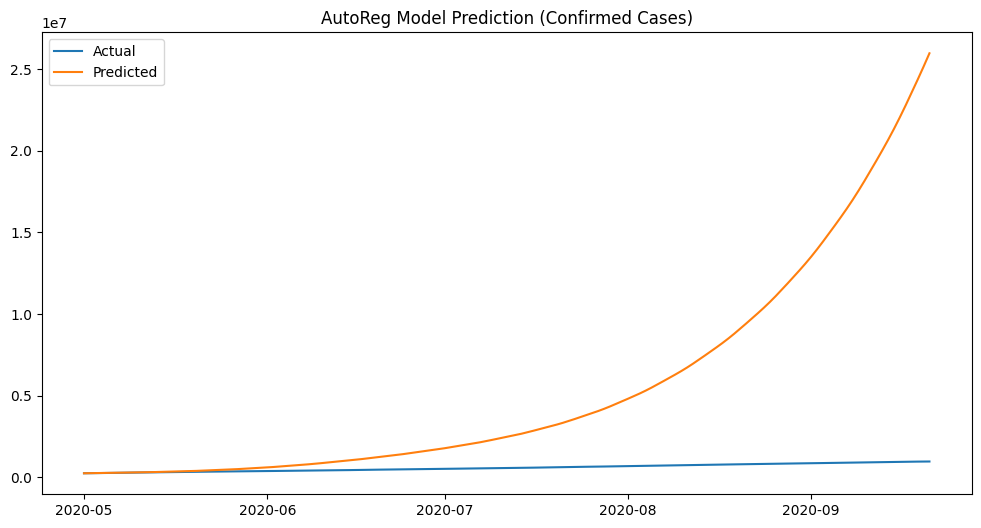

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(test, label='Actual')
plt.plot(prediction, label='Predicted')

plt.legend()
plt.title("AutoReg Model Prediction (Confirmed Cases)")
plt.show()

In [ ]:

from sklearn.metrics import mean_squared_error,mean_absolute_error

# Calculate mean squared error
mean_sq_error = mean_squared_error(test, prediction)

mean_abs_error = mean_absolute_error(test,prediction)
root_mean_squared_error = np.sqrt(mean_sq_error)
print(mean_sq_error)
print(root_mean_squared_error)
print(mean_abs_error)

65359895610864.695
8084546.716474876
4940705.4499136


In [ ]:
print("MSE:", mean_sq_error)
print("RMSE:", root_mean_squared_error)
print("MAE:", mean_abs_error)

MSE: 65359895610864.695
RMSE: 8084546.716474876
MAE: 4940705.4499136


In [ ]:
prediction = ar_model_fit.predict(start = 100,end = 200)

In [ ]:
prediction

,0
2020-05-01,2.426237e+05
2020-05-02,2.474182e+05
2020-05-03,2.515016e+05
2020-05-04,2.561454e+05
2020-05-05,2.621106e+05
...,...
2020-08-05,5.493361e+06
2020-08-06,5.688477e+06
2020-08-07,5.888064e+06
2020-08-08,6.088948e+06


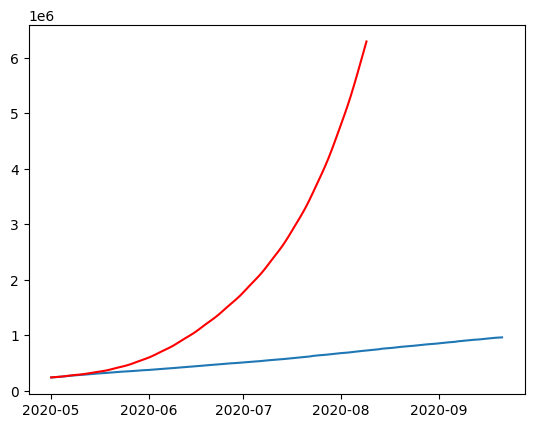

In [ ]:
import matplotlib.pyplot as plt

plt.plot(test)
plt.plot(prediction,color='red') #graph of test vs prediction
plt.show()

model next 30 days

In [ ]:
# Forecast next 30 days
future_steps = 30

future_forecast = ar_model_fit.predict(
    start=len(train) + len(test),
    end=len(train) + len(test) + future_steps - 1
)

print(future_forecast)

2020-09-22    2.684341e+07
2020-09-23    2.774345e+07
2020-09-24    2.868242e+07
2020-09-25    2.965103e+07
2020-09-26    3.064100e+07
2020-09-27    3.165221e+07
2020-09-28    3.269392e+07
2020-09-29    3.377889e+07
2020-09-30    3.491478e+07
2020-10-01    3.609902e+07
2020-10-02    3.732139e+07
2020-10-03    3.857247e+07
2020-10-04    3.985178e+07
2020-10-05    4.116953e+07
2020-10-06    4.254023e+07
2020-10-07    4.397298e+07
2020-10-08    4.546549e+07
2020-10-09    4.700655e+07
2020-10-10    4.858546e+07
2020-10-11    5.020136e+07
2020-10-12    5.186548e+07
2020-10-13    5.359434e+07
2020-10-14    5.539878e+07
2020-10-15    5.727688e+07
2020-10-16    5.921646e+07
2020-10-17    6.120543e+07
2020-10-18    6.324247e+07
2020-10-19    6.533999e+07
2020-10-20    6.751684e+07
2020-10-21    6.978589e+07
Freq: D, dtype: float64


In [ ]:
future_df = pd.DataFrame({
    "Day": range(1, future_steps+1),
    "Predicted Cases": future_forecast.values
})

future_df

,Day,Predicted Cases
0,1,2.684341e+07
1,2,2.774345e+07
2,3,2.868242e+07
3,4,2.965103e+07
4,5,3.064100e+07
5,6,3.165221e+07
6,7,3.269392e+07
7,8,3.377889e+07
8,9,3.491478e+07
9,10,3.609902e+07
